# RoBERTA on agnews
### LLM data generation: **"Llama-2-7b-chat-hf"**

https://huggingface.co/FacebookAI/roberta-base  
https://huggingface.co/FacebookAI/roberta-large

- total number of train samples: 500
- total number of test&nbsp; samples: 500
- classification model: "roberta-large"
- dataset: agnews

Generation methods:
- **A** generic augmentation
- **B** targeted augmentation
- **C** unsupervised context augmentation
- **D** real data with labels generated in zero-shot settings

TESTS:
1. 500 real
2. 250 real + 250 synthetic (A, B, C, D) [50% synthetic]
3. 50 real + 450 synthetic (A, B, C, D) [90% synthetic]
4. 500 synthetic (A, B, C, D) [100% synthetic]

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise
     
from src._utils._helpers import get_generated_examples_df
from src._utils._data_analysis_helpers import plot_f1_generationMethod
from src._utils._run_multiclassRoBERTA import main_multiclassRoBERTA

In [2]:
LLM_NAME = "Llama-2-7b-chat-hf"
LLM_NAME_ZEROSHOT = "Llama-2-7b-hf"
DATASET_NAME = "agnews"

FOLDER_DIR = "src/"+DATASET_NAME+"/experiments/RoBERTA_500samples/data_"+LLM_NAME
os.makedirs(FOLDER_DIR, exist_ok=True)
LOG_DIR = os.path.join(FOLDER_DIR, "RoBERTA_log.json")

### LOAD DATA ###
# real data
real_train_df = pd.read_csv("real_data/train/"+DATASET_NAME+"trainAll.csv").rename(columns={"2": "text", "3": "label"})
real_train_df.drop(columns=["0", "1"], inplace=True)

# Take 500 samples for dev set
real_train_df, dev_df = train_test_split(real_train_df, test_size=500, random_state=42, stratify=real_train_df["label"])
# Store the dev set into a CSV file
dev_df.to_csv(os.path.join(FOLDER_DIR, "dev_set.csv"), index=False)

# synthetic data (generic, targeted and unsupervised context)
SYNTHETIC_DATA_DIR = "synthetic_data/datasets/"+LLM_NAME+"/"
syn_generic_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_baseline_500.json")
syn_targeted_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_targeted+tags_500.json")
syn_targeted_df = syn_targeted_df.drop(columns=["phenomena"], inplace=False)
syn_unsupContext_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_unsupervisedContext_500.json")
syn_unsupContext_df = syn_unsupContext_df.drop(columns=["context_examples"])

In [3]:
# zeroshot data (real data + zeroshot generated labels)
data = "./src/"+DATASET_NAME+"/experiments/fewshotCasualLM_500samples/"+LLM_NAME_ZEROSHOT+"_zeroshot_TRAIN.csv"
zeroshot_df = pd.read_csv(data)

display(zeroshot_df.head())
acc = sum(zeroshot_df['label'] == zeroshot_df['predicted_label']) / len(zeroshot_df)
print(f"Accuracy {acc:.3f} | number of samples: {zeroshot_df.shape[0]}"),

# keep only the labels that are allowed
labels = zeroshot_df['label'].unique()
zeroshot_df = zeroshot_df[zeroshot_df["predicted_label"].isin(labels)].reset_index(drop=True)
new_acc = sum(zeroshot_df['label'] == zeroshot_df['predicted_label']) / len(zeroshot_df)

# set the predicted label as the real label for training
zeroshot_df['label'] = zeroshot_df["predicted_label"]
zeroshot_df = zeroshot_df.drop(columns=["predicted_label"])

print("Filter out labels that are not in the real data. Results:")
print(f"Accuracy {new_acc:.3f} | number of samples: {zeroshot_df.shape[0]}")

,text,label,predicted_label
0,Alternative Web browsers like Safari and Firef...,Sci/Tech,Business
1,NEW YORK - Eli Manning is undeniably the Giant...,Sports,Sports
2,BEIJING (Reuters) - Jelena Dokic ran true to ...,Sports,Sports
3,AP - A University of Idaho football player was...,Sports,Sports
4,&lt;p&gt;\&lt;/p&gt;&lt;p&gt; GENEVA (Reuters)...,Sci/Tech,Sci/Tech


Accuracy 0.659 | number of samples: 2179
Filter out labels that are not in the real data. Results:
Accuracy 0.697 | number of samples: 2062


In [4]:
results = []

def get_results(details):
    """Just get useful results from the details"""
    res = {}
    res["generation_method"] = details["generation_method"] if details["generation_method"] else "real"
    res["synthetic_ratio"] = details["synthetic_ratio"]
    for key, value in details["metrics_dev"].items():
        res[key] = value
    res["train_time"] = details["train_time"]
    res["eval_time"] = details["eval_time"]
    
    df = pd.DataFrame([res])
    display(df.round(3))
    return df

In [5]:
base_config = {
    "real_df": real_train_df,
    # "synth_df": None/syn_generic_df..,
    "dev_df": dev_df,
    # "synth_ratio": 0.0/0.5..,
    "max_samples": 500,
    "epochs": 8,
    "batch_size": 16,
    "output_dir": FOLDER_DIR,
    "log_dir": LOG_DIR,
    # "generation_method": None/"generic"/"targeted",
    "save_model": False,
    "save_dataset": True,
}

## 1. 500 real

In [6]:
config = base_config.copy()
config["synth_df"] = None
config["synth_ratio"] = 0.0
config["generation_method"] = None

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.780000,0.327064,0.914000,0.871225,0.914000
2,0.191400,0.405271,0.902000,0.838694,0.902000
3,0.105100,0.469049,0.906000,0.854241,0.906000
4,0.074300,0.500359,0.912000,0.870219,0.912000
5,0.032300,0.483489,0.924000,0.887166,0.924000
6,0.015700,0.500471,0.920000,0.881429,0.920000
7,0.003400,0.520338,0.922000,0.883845,0.922000
8,0.001500,0.527484,0.924000,0.887720,0.924000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,real,0.0,0.924,0.887,0.924,194.151,4.119


## 2. 250 real + 250 synthetic

A. Generic augmentation

In [7]:
config = base_config.copy()
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "generic"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.954200,0.303602,0.894000,0.838521,0.894000
2,0.187000,0.300543,0.912000,0.860452,0.912000
3,0.055000,0.503317,0.910000,0.860611,0.910000
4,0.041800,0.603910,0.902000,0.852694,0.902000
5,0.011400,0.590526,0.914000,0.869356,0.914000
6,0.001000,0.647475,0.902000,0.859371,0.902000
7,0.001300,0.647620,0.902000,0.856310,0.902000
8,0.000400,0.644780,0.904000,0.858424,0.904000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,generic,0.5,0.914,0.869,0.914,192.48,4.107


B. Targeted augmentation

In [8]:
config = base_config.copy()
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "targeted"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.843400,0.329820,0.904000,0.857120,0.904000
2,0.187400,0.444886,0.896000,0.835943,0.896000
3,0.090900,0.481568,0.904000,0.862035,0.904000
4,0.041700,0.604541,0.904000,0.857316,0.904000
5,0.027700,0.643491,0.890000,0.846508,0.890000
6,0.004700,0.641036,0.900000,0.858852,0.900000
7,0.001000,0.663746,0.906000,0.871120,0.906000
8,0.000400,0.664051,0.906000,0.870513,0.906000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,targeted,0.5,0.906,0.871,0.906,193.006,4.113


C. Unsupervised Context augmentation

In [9]:
config = base_config.copy()
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "unsupContext"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.807300,0.359010,0.878000,0.796835,0.878000
2,0.275100,0.355175,0.876000,0.817550,0.876000
3,0.139600,0.560166,0.866000,0.806295,0.866000
4,0.074100,0.623294,0.878000,0.813569,0.878000
5,0.024000,0.691665,0.884000,0.819847,0.884000
6,0.006700,0.735694,0.880000,0.815386,0.880000
7,0.000800,0.734090,0.874000,0.820081,0.874000
8,0.000700,0.748723,0.878000,0.822315,0.878000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,unsupContext,0.5,0.884,0.82,0.884,192.596,4.104


D. Zeroshot labels

In [10]:
config = base_config.copy()
config["synth_df"] = zeroshot_df # real data with labels predicted in zero-shot setting
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "zeroshotLabels"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.252500,0.492776,0.904000,0.848671,0.904000
2,0.596900,0.300449,0.912000,0.872366,0.912000
3,0.399900,0.316143,0.910000,0.875758,0.910000
4,0.265600,0.461254,0.864000,0.829605,0.864000
5,0.164400,0.433050,0.882000,0.846509,0.882000
6,0.079600,0.529020,0.860000,0.829810,0.860000
7,0.035800,0.480209,0.892000,0.858326,0.892000
8,0.022300,0.515445,0.874000,0.840733,0.874000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,zeroshotLabels,0.5,0.912,0.872,0.912,191.101,4.116


## 3. 50 real + 450 synthetic
A. Generic augmentation

In [11]:
config = base_config.copy()
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "generic"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.864500,0.687254,0.738000,0.723225,0.738000
2,0.098100,0.844318,0.768000,0.724249,0.768000
3,0.039900,0.707411,0.844000,0.779486,0.844000
4,0.003400,0.772072,0.866000,0.801333,0.866000
5,0.000600,0.858356,0.860000,0.795317,0.860000
6,0.000400,0.931932,0.850000,0.782299,0.850000
7,0.000300,0.930494,0.854000,0.786136,0.854000
8,0.000300,0.933330,0.854000,0.786136,0.854000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,generic,0.9,0.866,0.801,0.866,191.793,4.106


B. Targeted augmentation

In [12]:
config = base_config.copy()
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "targeted"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.952400,1.019282,0.540000,0.532303,0.540000
2,0.180300,0.621801,0.812000,0.731157,0.812000
3,0.042500,0.672004,0.838000,0.754312,0.838000
4,0.003900,0.668749,0.848000,0.779507,0.848000
5,0.001100,0.711106,0.852000,0.783946,0.852000
6,0.000400,0.704371,0.856000,0.786722,0.856000
7,0.000300,0.705796,0.854000,0.784631,0.854000
8,0.000300,0.703734,0.858000,0.791359,0.858000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,targeted,0.9,0.858,0.791,0.858,191.443,4.106


C. Unsupervised Context augmentation

In [13]:
config = base_config.copy()
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "unsupContext"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.875300,0.841718,0.642000,0.626378,0.642000
2,0.188300,1.136556,0.666000,0.641136,0.666000
3,0.132100,0.861159,0.774000,0.739309,0.774000
4,0.059400,1.055868,0.772000,0.742671,0.772000
5,0.034500,1.272524,0.736000,0.696559,0.736000
6,0.003200,1.034576,0.810000,0.750466,0.810000
7,0.001300,1.016622,0.818000,0.758294,0.818000
8,0.000600,1.035497,0.820000,0.759791,0.820000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,unsupContext,0.9,0.82,0.76,0.82,191.622,4.113


D. Zeroshot labels

In [14]:
config = base_config.copy()
config["synth_df"] = zeroshot_df # real data with labels predicted in zero-shot setting
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "zeroshotLabels"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.290000,0.514762,0.878000,0.796486,0.878000
2,0.687500,0.669994,0.762000,0.746360,0.762000
3,0.505400,0.519766,0.848000,0.812892,0.848000
4,0.348000,0.585849,0.836000,0.805998,0.836000
5,0.201900,0.662180,0.820000,0.788825,0.820000
6,0.110500,0.728041,0.842000,0.807917,0.842000
7,0.060800,0.813308,0.812000,0.775844,0.812000
8,0.044900,0.799686,0.818000,0.780424,0.818000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,zeroshotLabels,0.9,0.878,0.796,0.878,188.932,4.116


## 4. 500 synthetic
A. Generic augmentation

In [15]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "generic"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.768100,1.785565,0.480000,0.464302,0.480000
2,0.017100,2.667301,0.588000,0.531216,0.588000
3,0.000700,2.833676,0.620000,0.582750,0.620000
4,0.000400,3.024522,0.616000,0.576096,0.616000
5,0.000300,3.099512,0.610000,0.565345,0.610000
6,0.000300,3.154810,0.610000,0.565345,0.610000
7,0.000300,3.180859,0.610000,0.565835,0.610000
8,0.000300,3.189288,0.610000,0.565835,0.610000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,generic,1.0,0.62,0.583,0.62,192.256,4.114


B. Targeted augmentation

In [16]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "targeted"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.718100,1.400803,0.420000,0.442615,0.420000
2,0.034200,1.675835,0.644000,0.625047,0.644000
3,0.000700,3.097284,0.588000,0.531154,0.588000
4,0.000400,3.083698,0.598000,0.553964,0.598000
5,0.000300,3.100742,0.600000,0.558169,0.600000
6,0.000200,3.115800,0.600000,0.558169,0.600000
7,0.000200,3.131982,0.600000,0.558169,0.600000
8,0.000200,3.138719,0.600000,0.558169,0.600000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,targeted,1.0,0.644,0.625,0.644,192.449,4.106


C. Unsupervised Context augmentation

In [17]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "unsupContext"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.922400,1.240138,0.628000,0.583566,0.628000
2,0.163400,2.253297,0.628000,0.598542,0.628000
3,0.070300,2.441868,0.568000,0.555105,0.568000
4,0.060800,2.548099,0.632000,0.589769,0.632000
5,0.014700,2.689898,0.616000,0.583879,0.616000
6,0.020100,2.419590,0.638000,0.607939,0.638000
7,0.000600,2.793764,0.628000,0.594697,0.628000
8,0.006400,2.815684,0.626000,0.594046,0.626000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,unsupContext,1.0,0.638,0.608,0.638,191.797,4.111


D. Zeroshot labels

In [6]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = zeroshot_df # real data with labels predicted in zero-shot setting
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "zeroshotLabels"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.203800,0.535231,0.862000,0.823841,0.862000
2,0.756400,0.517657,0.832000,0.770045,0.832000
3,0.520800,0.790933,0.734000,0.710772,0.734000
4,0.310000,0.512269,0.844000,0.807312,0.844000
5,0.172900,0.826948,0.796000,0.767754,0.796000
6,0.092500,1.063416,0.770000,0.744265,0.770000
7,0.055400,1.060627,0.768000,0.738628,0.768000
8,0.033800,1.079913,0.778000,0.749598,0.778000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,zeroshotLabels,1.0,0.862,0.824,0.862,195.152,4.124



---
# Results

In [ ]:
df_results = pd.concat(results).reset_index(drop=True)
df_results.to_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"), index=False)
display(df_results.round(3))

,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,real,0.0,0.926,0.889,0.926,196.975,4.137
1,generic,0.5,0.914,0.869,0.914,192.480,4.107
2,targeted,0.5,0.906,0.871,0.906,193.006,4.113
3,unsupContext,0.5,0.884,0.820,0.884,192.596,4.104
4,zeroshotLabels,0.5,0.912,0.872,0.912,191.101,4.116
5,generic,0.9,0.866,0.801,0.866,191.793,4.106
6,targeted,0.9,0.858,0.791,0.858,191.443,4.106
7,unsupContext,0.9,0.820,0.760,0.820,191.622,4.113
8,zeroshotLabels,0.9,0.878,0.796,0.878,188.932,4.116
9,generic,1.0,0.620,0.583,0.620,192.256,4.114


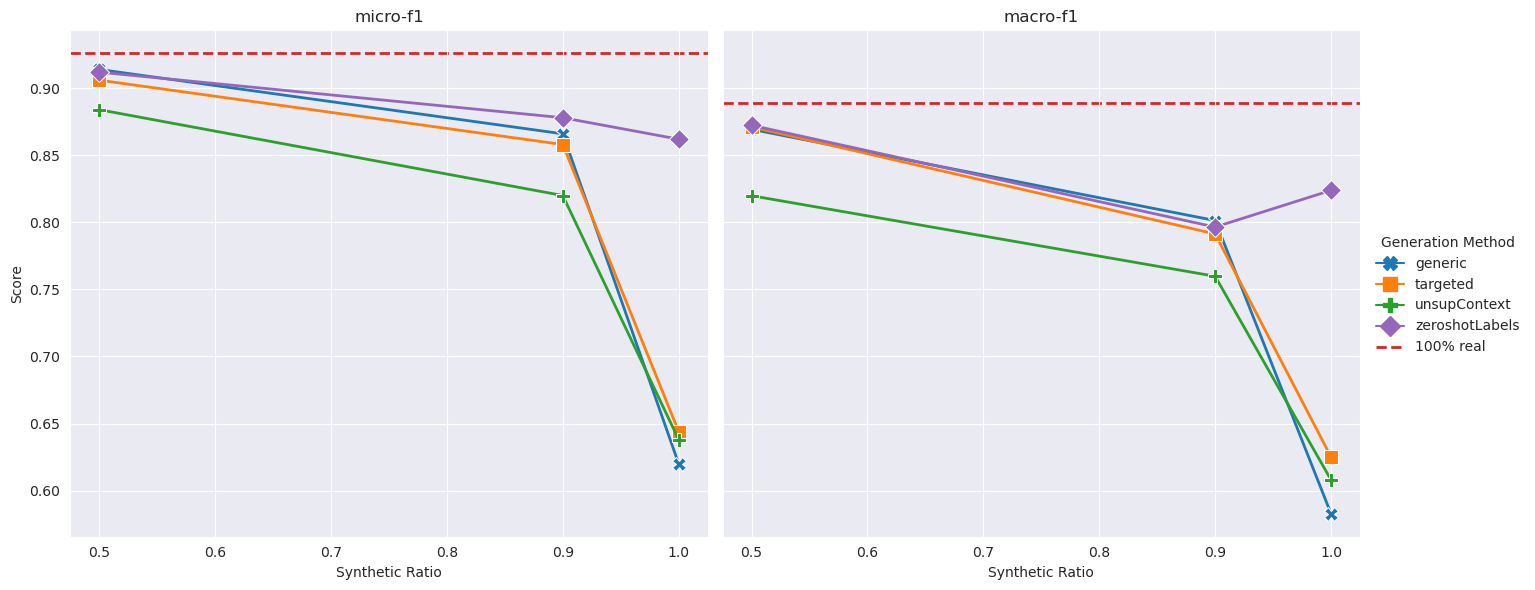

In [5]:
df_results = pd.read_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"))

plot_f1_generationMethod(df=df_results, x_col="synthetic_ratio", hue_col="generation_method")